# IS2SMGPSIT-V1 winter Arctic sea ice maps

**Summary**: Winter (November–April) mean maps and multi-winter anomaly maps of sea ice thickness, freeboard, and snow depth from the daily IS2SMGPSIT-V1 fused product, following the same layout used in the IS2SITMOGR4-V4 update notebook (`2e`).

**Author**: Alek Petty  
**Version history**: Version 1 (08/2026)


In [1]:
### Import notebook dependencies

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
import warnings

from utils.read_data_utils import read_is2smgpsitv1_zarr
from utils.plotting_utils import staticArcticMaps_equal_panels, compute_gridcell_winter_means

mpl.rcParams['figure.dpi'] = 200
warnings.filterwarnings('ignore')


In [2]:
# Set some plotting parameters
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "mathtext.fontset": "stixsans",
    "lines.linewidth": 1.0,
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})
mpl.rcParams['font.sans-serif'] = ['Arial']


## Load IS2SMGPSIT-V1

Read the daily fused product (local cache preferred). Resample to monthly means on month-start timestamps so the same `compute_gridcell_winter_means` helper used in notebook `2e` can build November–April winter means.


In [3]:
%%time
# Consumer notebooks: reuse the local Zarr cache built by 11a when available
IS2_SMOS_SMAP = read_is2smgpsitv1_zarr(load_cache=True, persist=False)
print(IS2_SMOS_SMAP)
print('time range:', IS2_SMOS_SMAP.time.values.min(), '→', IS2_SMOS_SMAP.time.values.max())


Loading IS2-SMOS-SMAP (is2smsitgp) Zarr from local cache
cache_path: ./data/cache/GPSat_multivar_20181101-20250430.zarr
<xarray.Dataset> Size: 4GB
Dimensions:                             (time: 1635, y: 448, x: 304)
Coordinates:
    latitude                            (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    longitude                           (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
  * time                                (time) datetime64[ns] 13kB 2018-11-01...
  * x                                   (x) float32 1kB -3.838e+06 ... 3.738e+06
  * y                                   (y) float32 2kB 5.838e+06 ... -5.338e+06
Data variables: (12/13)
    crs                                 (time) int32 7kB dask.array<chunksize=(100,), meta=np.ndarray>
    freeboard                           (time, y, x) float32 891MB dask.array<chunksize=(100, 448, 304), meta=np.ndarray>
    grid_cell_area                      (y, x) float32 54

In [4]:
# Monthly means (month-start labels) for winter aggregation / map plotting
# Matches the monthly cadence of IS2SITMOGR4 used in notebook 2e.
IS2_monthly = IS2_SMOS_SMAP[['ice_thickness', 'freeboard', 'snow_depth']].resample(time='1MS').mean()
IS2_monthly = IS2_monthly.assign_coords(
    latitude=IS2_SMOS_SMAP.latitude,
    longitude=IS2_SMOS_SMAP.longitude,
)
print(IS2_monthly)
print('monthly times:', IS2_monthly.time.values[0], '→', IS2_monthly.time.values[-1],
      f'({IS2_monthly.sizes["time"]} months)')


<xarray.Dataset> Size: 129MB
Dimensions:        (x: 304, y: 448, time: 78)
Coordinates:
  * x              (x) float32 1kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y              (y) float32 2kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
  * time           (time) datetime64[ns] 624B 2018-11-01 ... 2025-04-01
    latitude       (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    longitude      (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
Data variables:
    ice_thickness  (time, y, x) float32 42MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard      (time, y, x) float32 42MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth     (time, y, x) float32 42MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    caa_uncertainty_caution:    Canadian Arctic Archipelago (CAA; NSIDC-0780 ...
    contact:                    Alek Petty (akpetty@umd.edu)
    description:                IC

## Winter mean maps

Compute November–April grid-cell means for winters starting 2018 through 2024 (seven growth seasons, through April 2025), then plot absolute fields and anomalies relative to the seven-winter mean — same approach and `staticArcticMaps_equal_panels` layout as notebook `2e`.


In [5]:
# Years over which to perform analysis (start year of that winter period)
years = [x for x in range(2018, 2024 + 1)]

freeboard_winter_means = compute_gridcell_winter_means(IS2_monthly.freeboard, years=years)
snow_depth_winter_means = compute_gridcell_winter_means(IS2_monthly.snow_depth, years=years)
thickness_winter_means = compute_gridcell_winter_means(IS2_monthly.ice_thickness, years=years)

# Open-water / missing *ocean* cells are NaN; set those to 0 for mapping.
# Leave land (region_mask outside 1–18) as NaN so Natural Earth land can overlay cleanly.
_rm = IS2_SMOS_SMAP['region_mask']
if 'time' in _rm.dims:
    _rm = _rm.isel(time=0, drop=True)
_ocean = _rm.isin(list(range(1, 19))).compute()

def _fill_open_water(da):
    # Fill open-water NaNs only in ocean regions 1–18 (not land 0/30+)
    return da.fillna(0).where(_ocean)

freeboard_winter_means = _fill_open_water(freeboard_winter_means)
snow_depth_winter_means = _fill_open_water(snow_depth_winter_means)
thickness_winter_means = _fill_open_water(thickness_winter_means)

print('winters:', list(thickness_winter_means.time.values))
print('thickness winter means shape:', thickness_winter_means.shape)


winters: ['Nov 2018 - Apr 2019', 'Nov 2019 - Apr 2020', 'Nov 2020 - Apr 2021', 'Nov 2021 - Apr 2022', 'Nov 2022 - Apr 2023', 'Nov 2023 - Apr 2024', 'Nov 2024 - Apr 2025']
thickness winter means shape: (7, 448, 304)


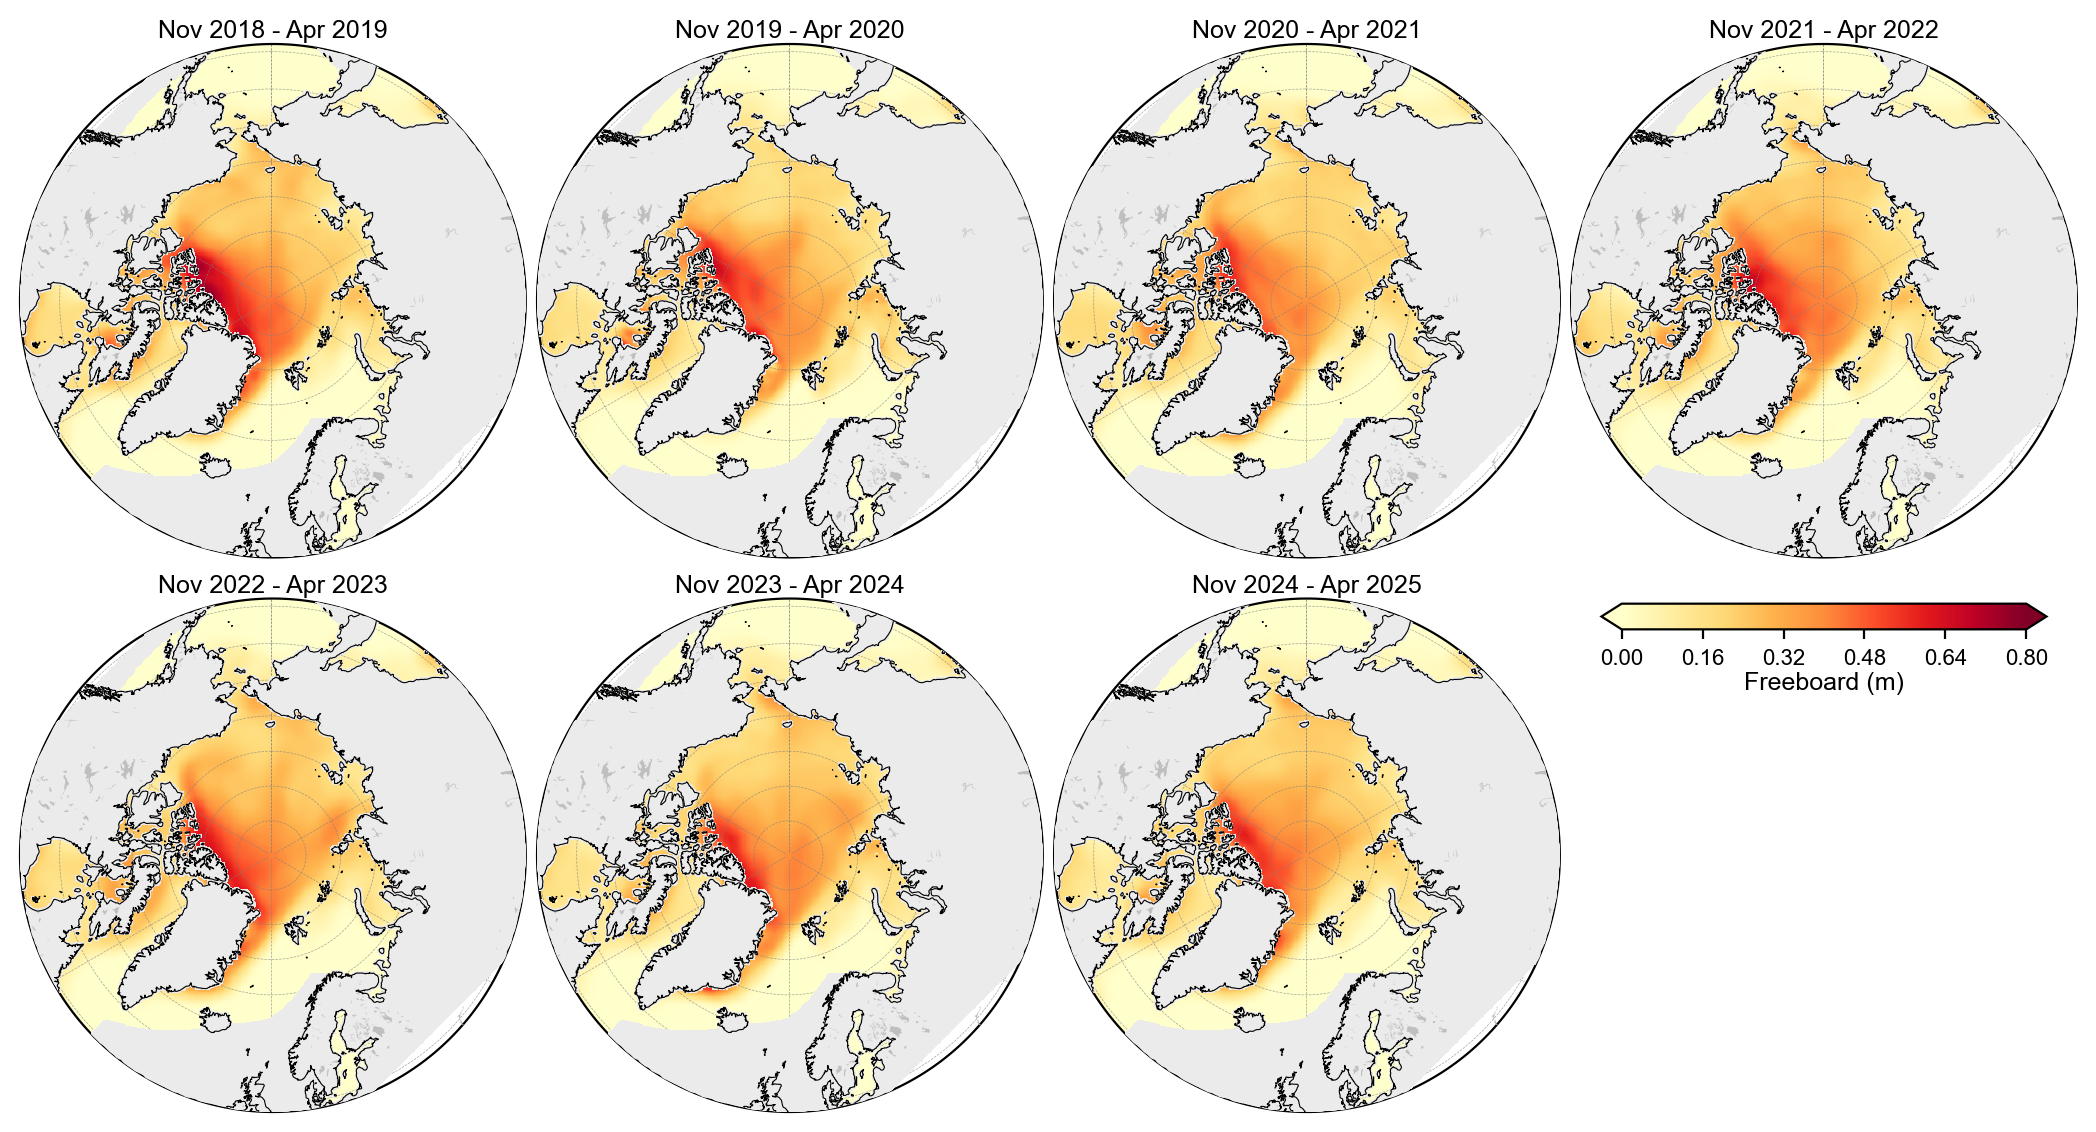

In [6]:
staticArcticMaps_equal_panels(
    freeboard_winter_means,
    dates=freeboard_winter_means.time.values,
    title="",
    set_cbarlabel="Freeboard (m)",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.8,
    out_str='freeboard_winter_2018_2025_is2smgpsitv1',
    ocean_mask=_ocean.values,
)


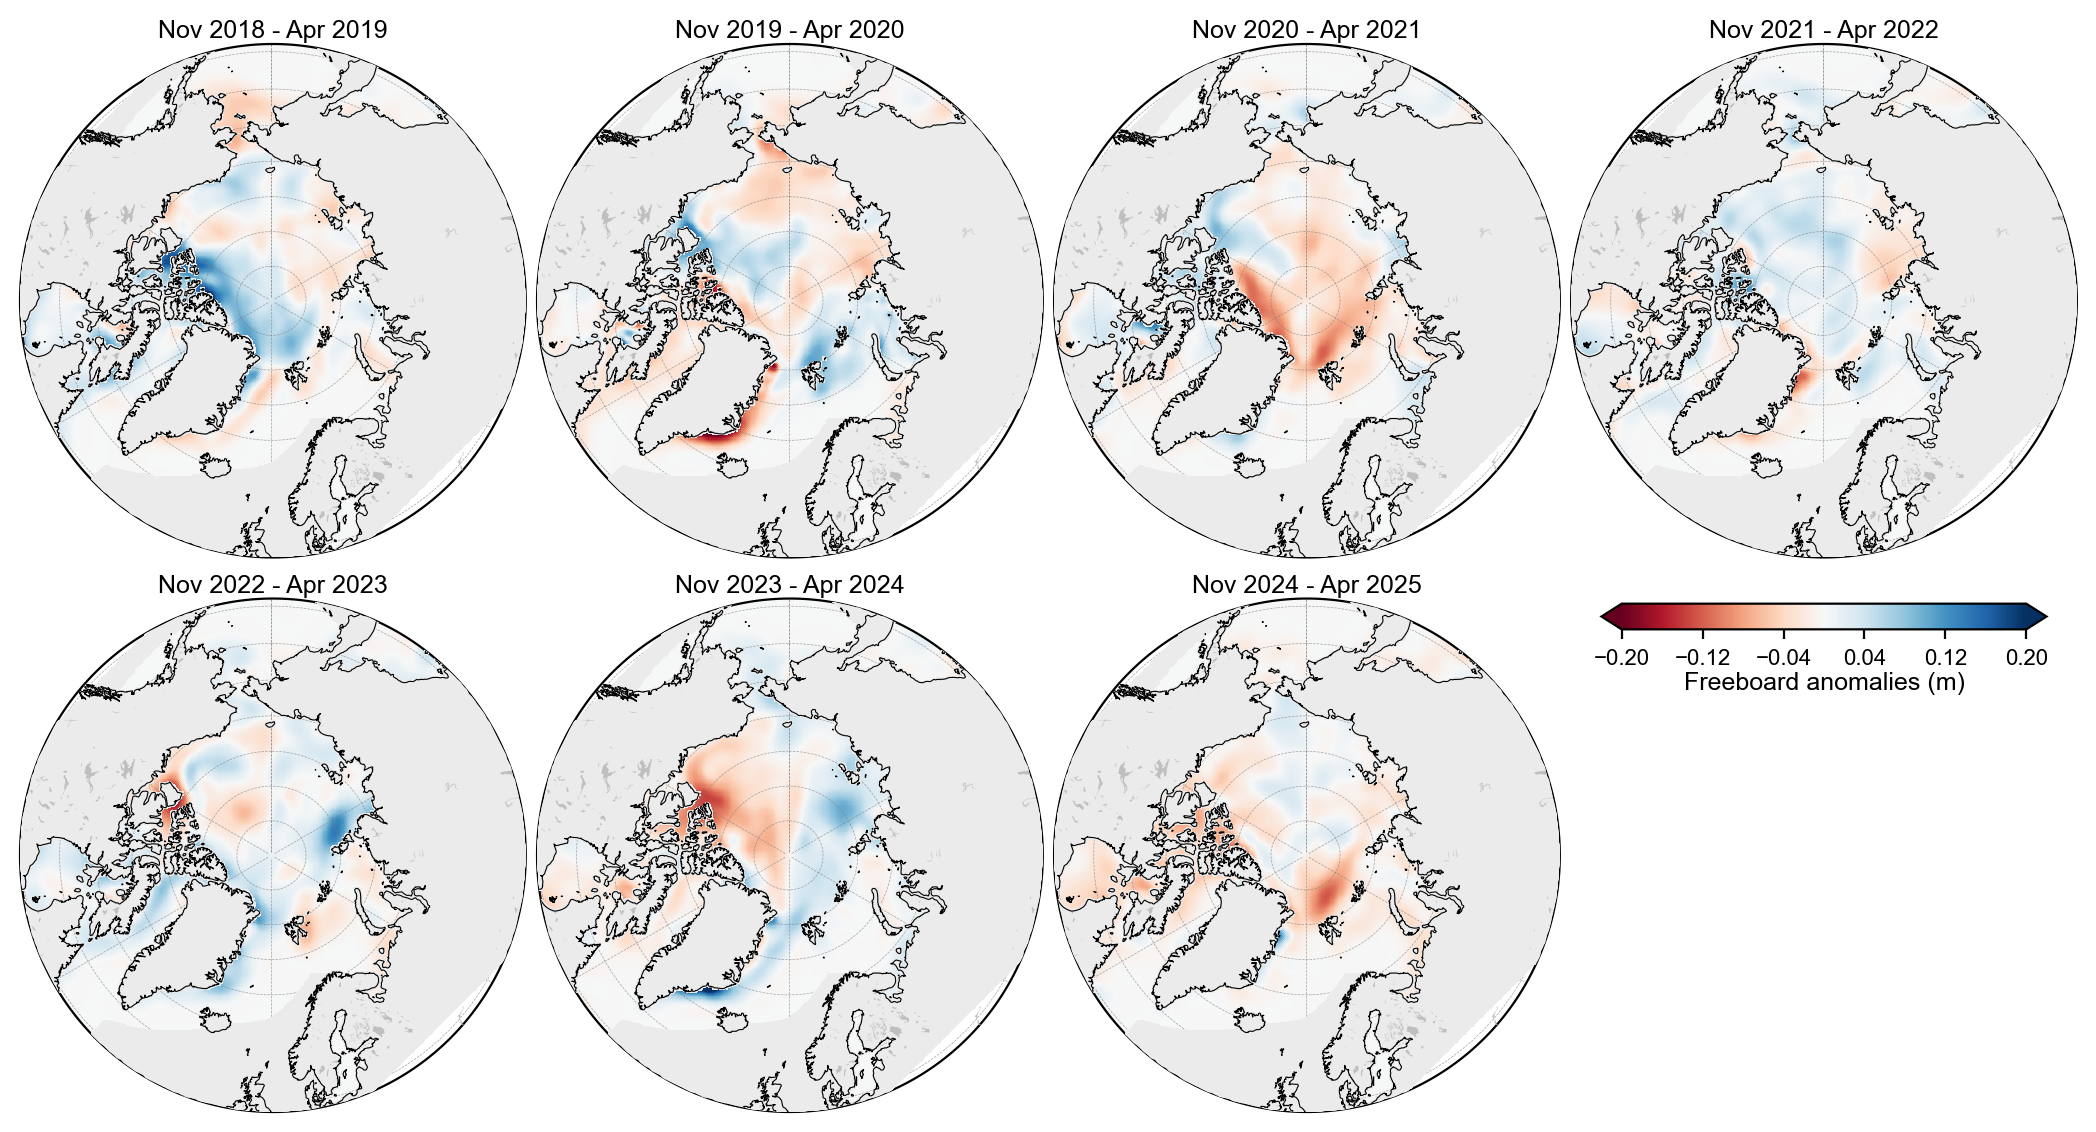

In [7]:
staticArcticMaps_equal_panels(
    freeboard_winter_means - freeboard_winter_means.mean("time"),
    dates=freeboard_winter_means.time.values,
    title="",
    set_cbarlabel="Freeboard anomalies (m)",
    cmap="RdBu",
    vmin=-0.2,
    vmax=0.2,
    out_str='freeboard_winter_2018_2025_anoms_is2smgpsitv1',
    ocean_mask=_ocean.values,
)


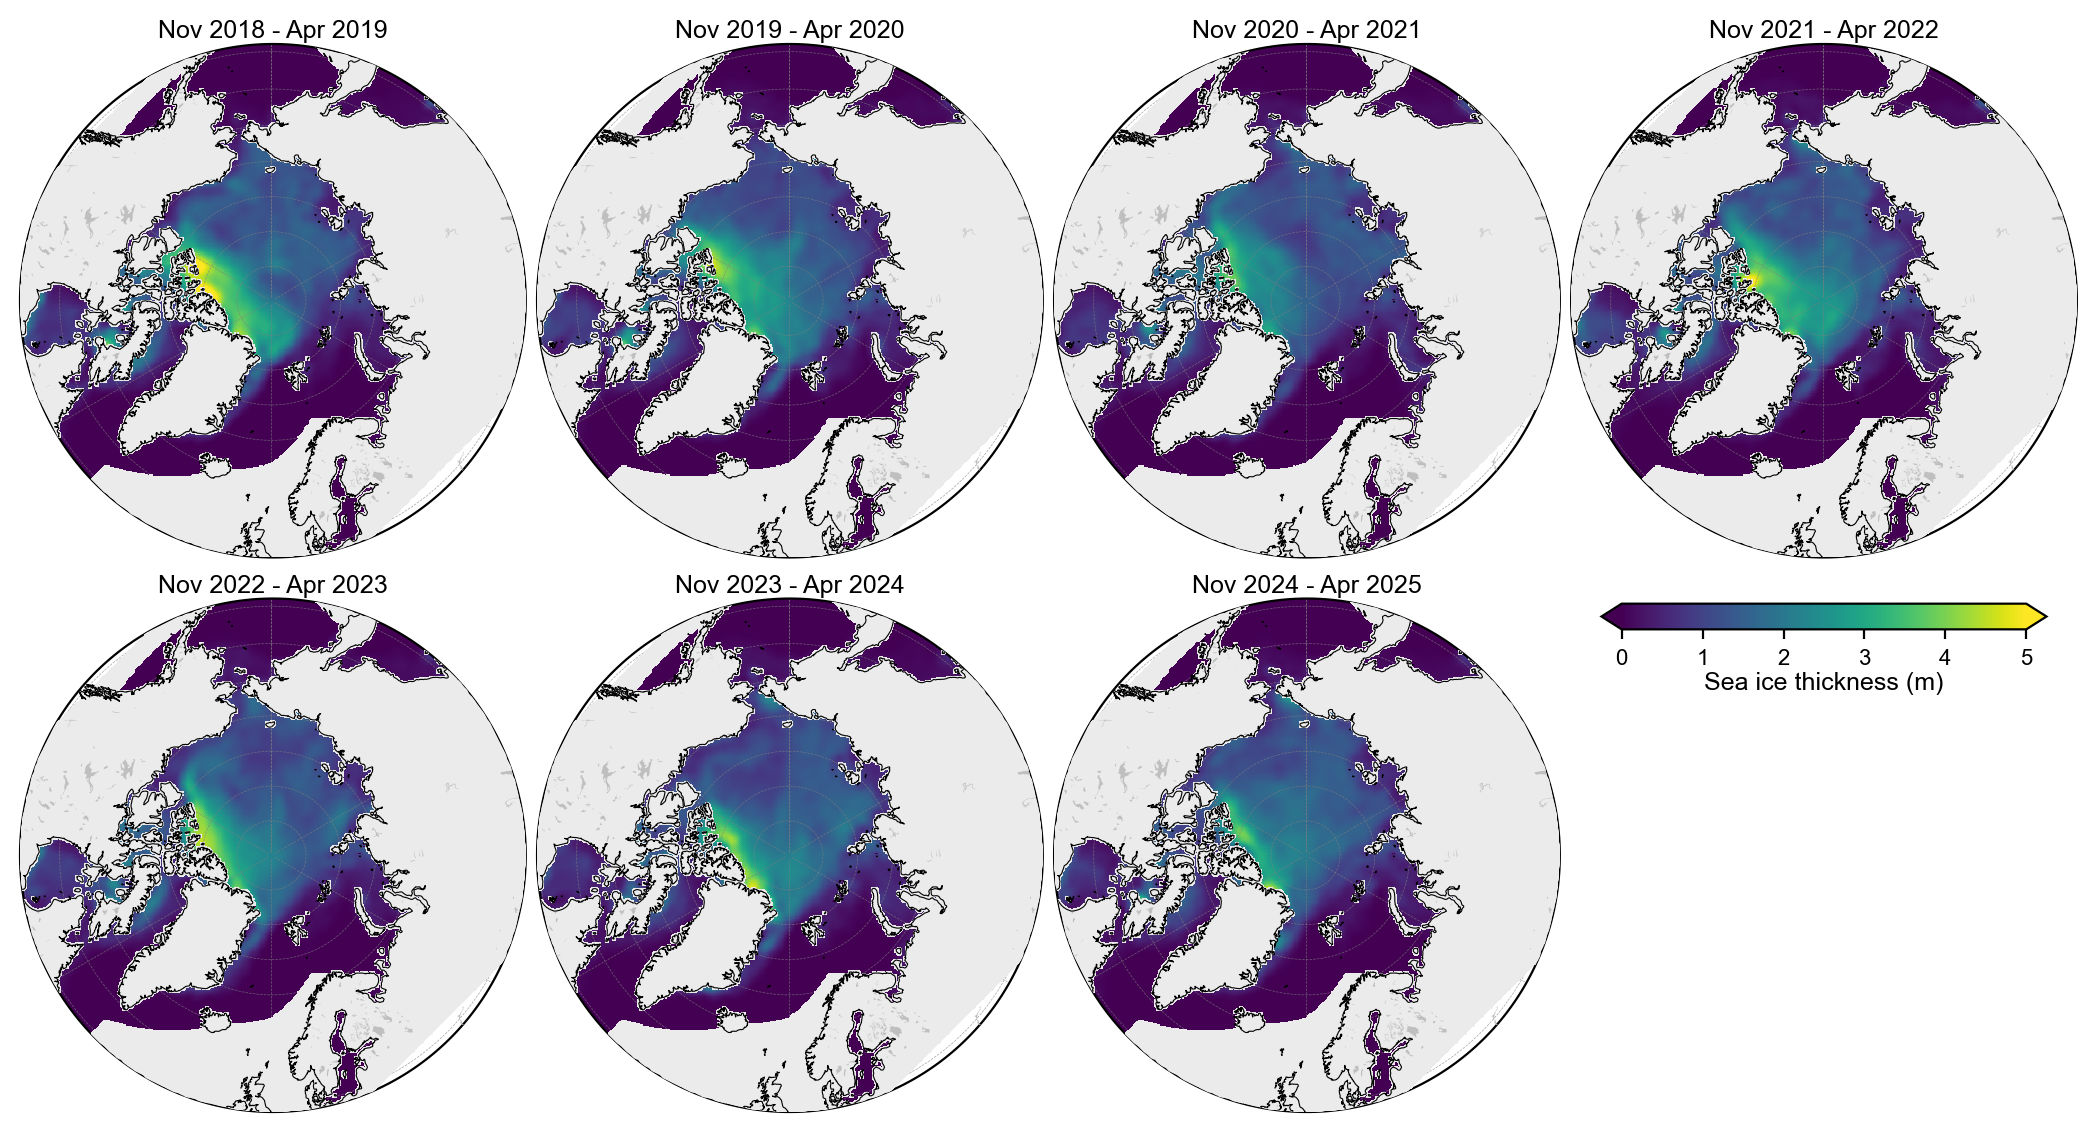

In [8]:
staticArcticMaps_equal_panels(
    thickness_winter_means,
    dates=thickness_winter_means.time.values,
    title="",
    set_cbarlabel="Sea ice thickness (m)",
    cmap="viridis",
    vmin=0,
    vmax=5,
    out_str='thickness_winter_2018_2025_is2smgpsitv1',
    ocean_mask=_ocean.values,
)


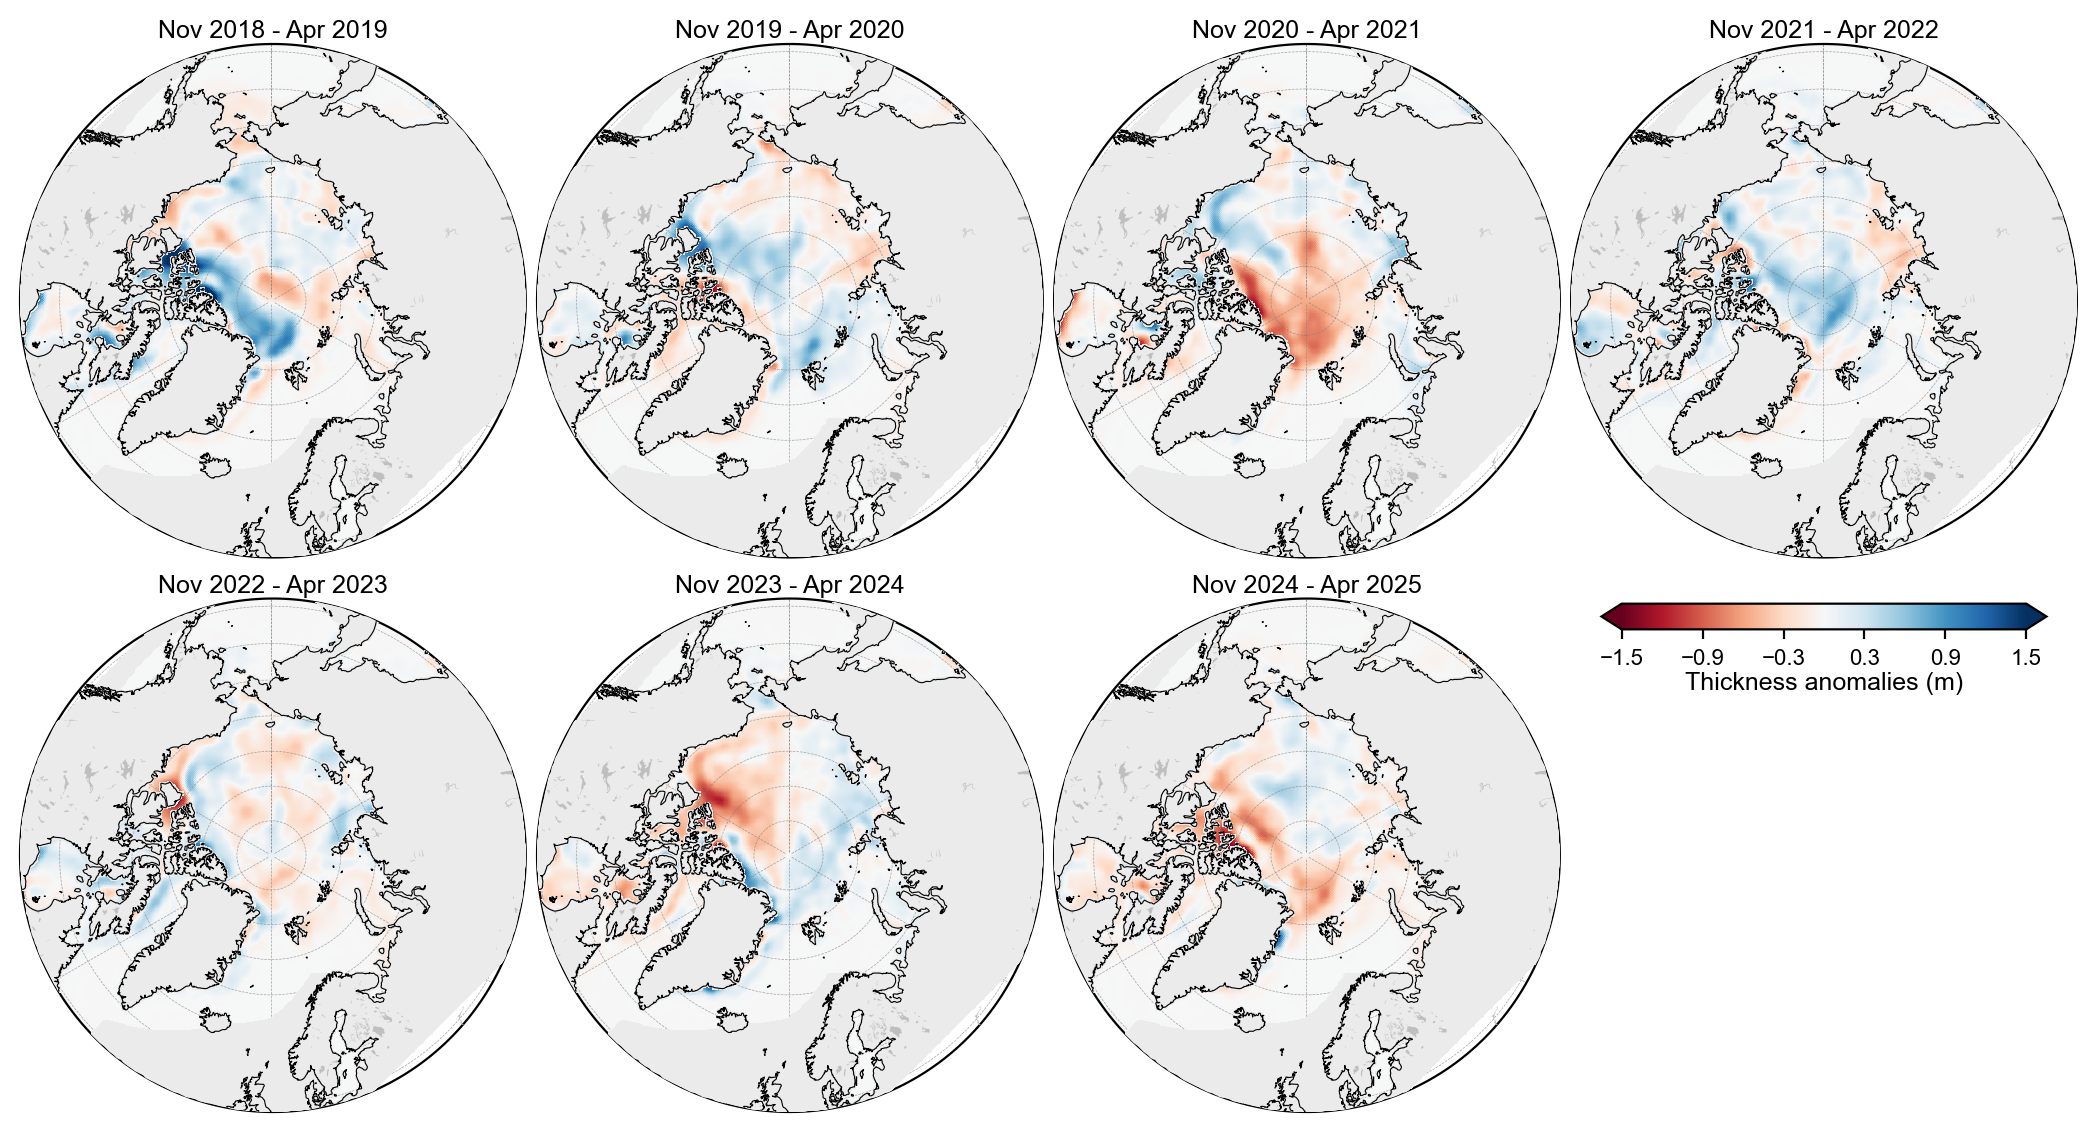

In [9]:
staticArcticMaps_equal_panels(
    thickness_winter_means - thickness_winter_means.mean("time"),
    dates=thickness_winter_means.time.values,
    title="",
    set_cbarlabel="Thickness anomalies (m)",
    cmap="RdBu",
    vmin=-1.5,
    vmax=1.5,
    out_str='thickness_winter_2018_2025_anomalies_is2smgpsitv1',
    ocean_mask=_ocean.values,
)


April anomaly times: [Timestamp('2019-04-01 00:00:00'), Timestamp('2020-04-01 00:00:00'), Timestamp('2021-04-01 00:00:00'), Timestamp('2022-04-01 00:00:00'), Timestamp('2023-04-01 00:00:00'), Timestamp('2024-04-01 00:00:00'), Timestamp('2025-04-01 00:00:00')]


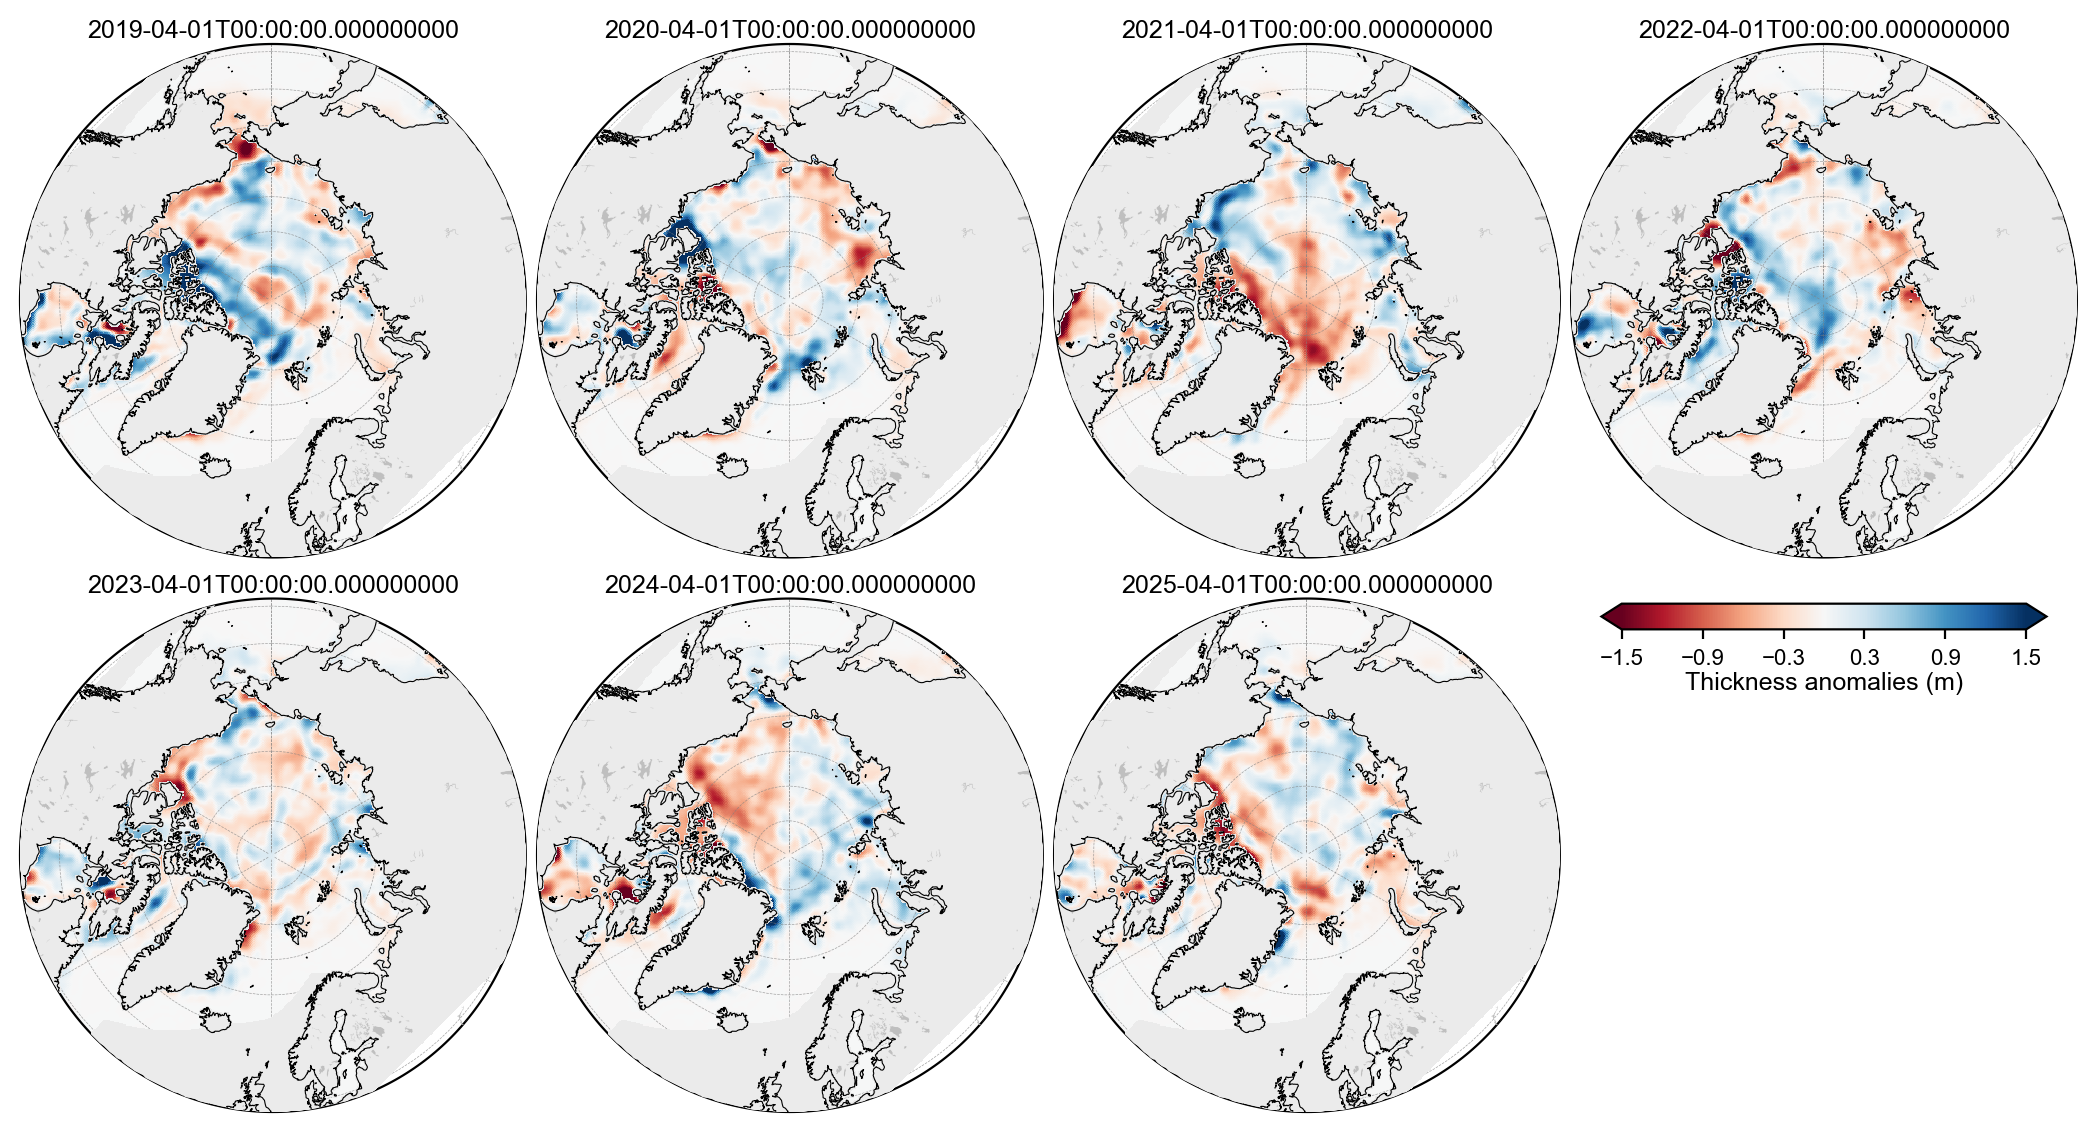

In [10]:
# April-only thickness anomalies (same idea as notebook 2e)
# Use .sel (not .where) so only the ~7 April months remain on the time axis.
mask = IS2_monthly.time.dt.month == 4
april_thickness = _fill_open_water(IS2_monthly.ice_thickness.sel(time=mask))
april_anom = _fill_open_water(april_thickness - april_thickness.mean('time'))
print('April anomaly times:', list(pd.to_datetime(april_anom.time.values)))
staticArcticMaps_equal_panels(
    april_anom,
    dates=april_anom.time.values,
    title="",
    set_cbarlabel="Thickness anomalies (m)",
    cmap="RdBu",
    vmin=-1.5,
    vmax=1.5,
    out_str='thickness_april_2019_2025_anomalies_is2smgpsitv1',
    ocean_mask=_ocean.values,
)


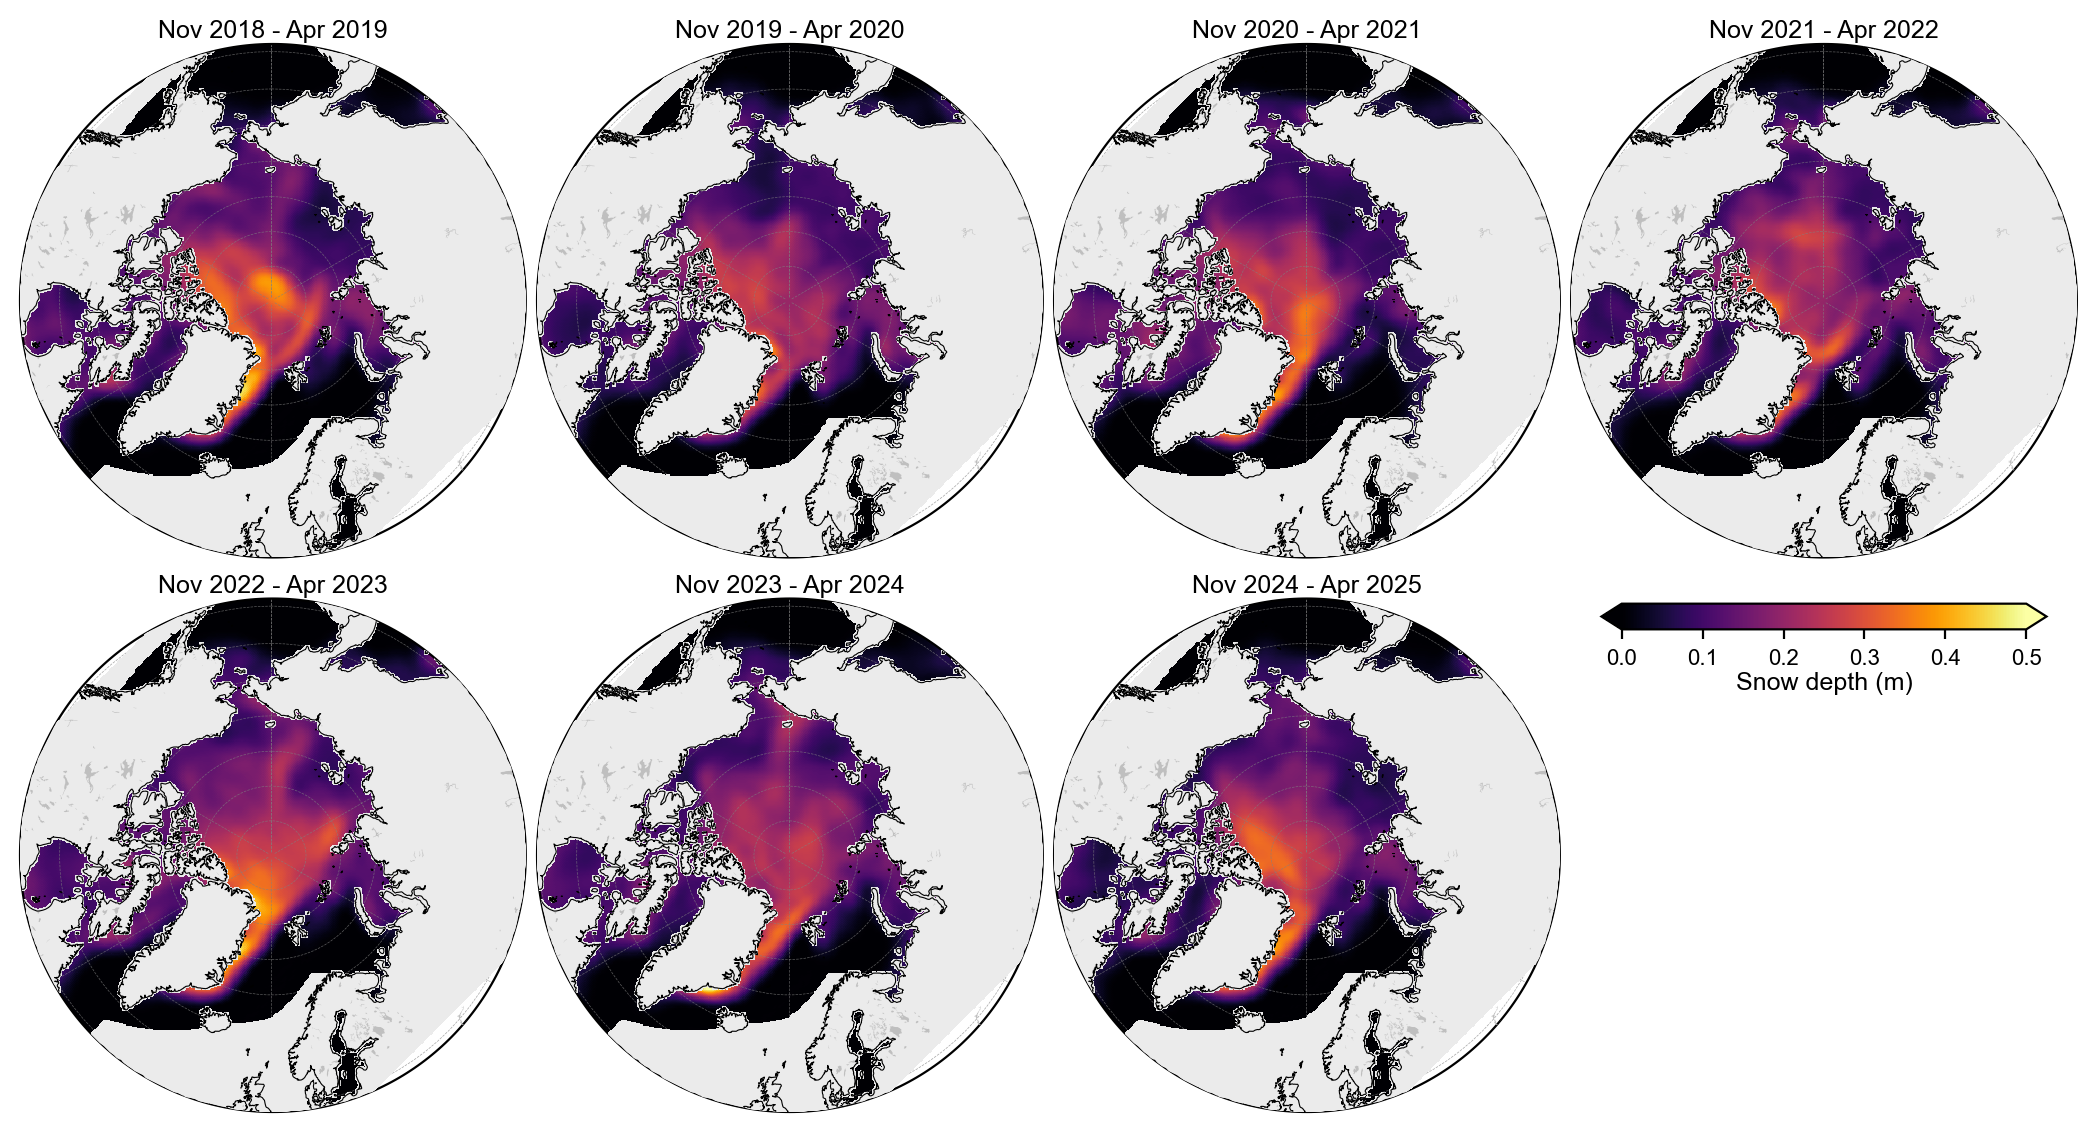

In [11]:
staticArcticMaps_equal_panels(
    snow_depth_winter_means,
    dates=snow_depth_winter_means.time.values,
    title="",
    set_cbarlabel="Snow depth (m)",
    cmap="inferno",
    vmin=0,
    vmax=0.5,
    out_str='snow_depth_winter_2018_2025_is2smgpsitv1',
    ocean_mask=_ocean.values,
)


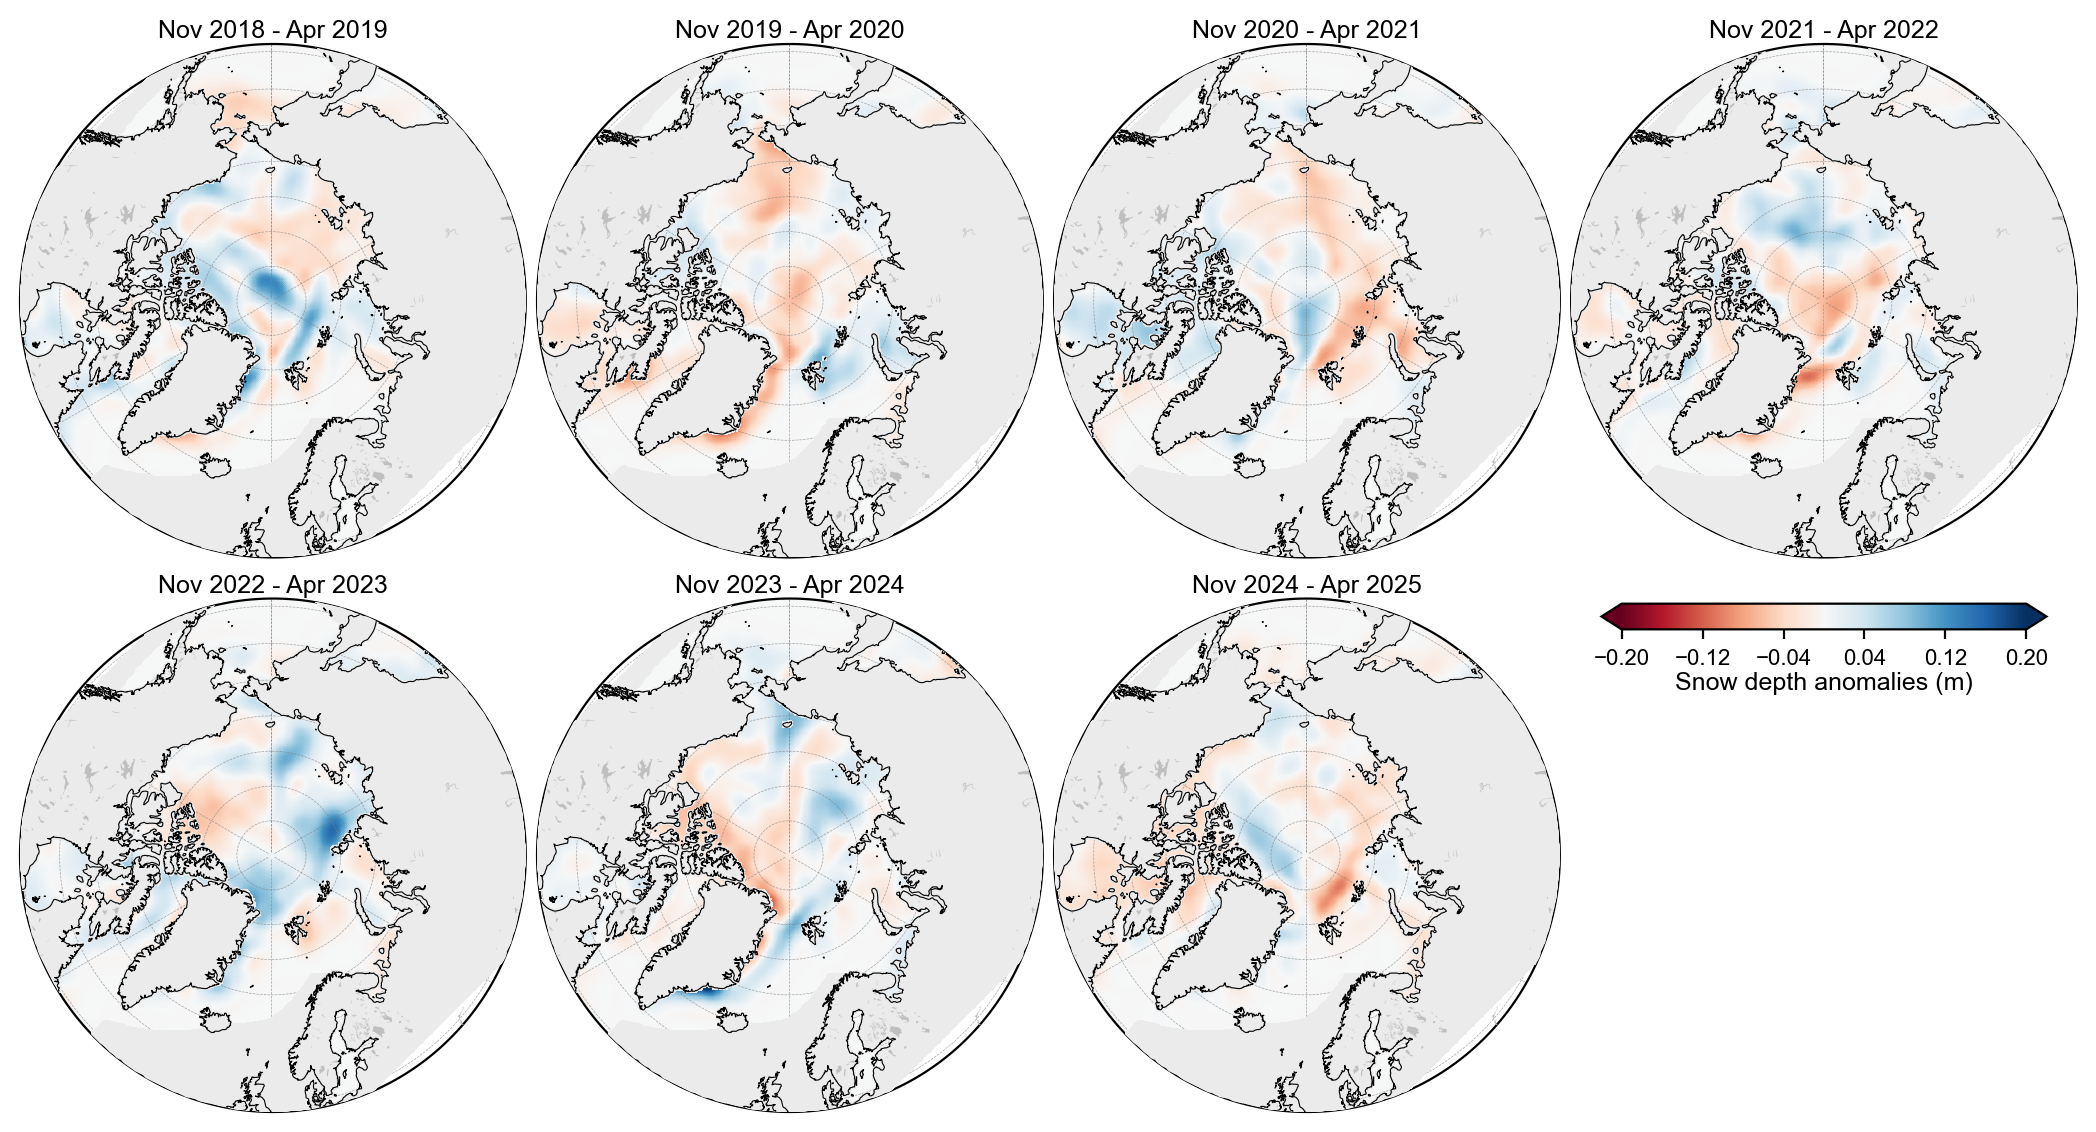

In [12]:
staticArcticMaps_equal_panels(
    snow_depth_winter_means - snow_depth_winter_means.mean("time"),
    dates=snow_depth_winter_means.time.values,
    title="",
    set_cbarlabel="Snow depth anomalies (m)",
    cmap="RdBu",
    vmin=-0.2,
    vmax=0.2,
    out_str='snow_depth_winter_2018_2025_anoms_is2smgpsitv1',
    ocean_mask=_ocean.values,
)


In [13]:
# Also keep paper copies of the winter map figures
from pathlib import Path
import shutil
fig_dir = Path('./figs')
paper_dir = Path('../paper/figures')
paper_dir.mkdir(parents=True, exist_ok=True)
for src in sorted(fig_dir.glob('maps_*_is2smgpsitv1.png')):
    dst = paper_dir / src.name
    shutil.copy2(src, dst)
    print('copied', src.name, '→', dst)


copied maps_freeboard_winter_2018_2025_anoms_is2smgpsitv1.png → ../paper/figures/maps_freeboard_winter_2018_2025_anoms_is2smgpsitv1.png
copied maps_freeboard_winter_2018_2025_is2smgpsitv1.png → ../paper/figures/maps_freeboard_winter_2018_2025_is2smgpsitv1.png
copied maps_snow_depth_winter_2018_2025_anoms_is2smgpsitv1.png → ../paper/figures/maps_snow_depth_winter_2018_2025_anoms_is2smgpsitv1.png
copied maps_snow_depth_winter_2018_2025_is2smgpsitv1.png → ../paper/figures/maps_snow_depth_winter_2018_2025_is2smgpsitv1.png
copied maps_thickness_april_2019_2025_anomalies_is2smgpsitv1.png → ../paper/figures/maps_thickness_april_2019_2025_anomalies_is2smgpsitv1.png
copied maps_thickness_winter_2018_2025_anomalies_is2smgpsitv1.png → ../paper/figures/maps_thickness_winter_2018_2025_anomalies_is2smgpsitv1.png
copied maps_thickness_winter_2018_2025_is2smgpsitv1.png → ../paper/figures/maps_thickness_winter_2018_2025_is2smgpsitv1.png


## Notes

- Winter means use **November–April** (same default as `compute_gridcell_winter_means` / notebook `2e`).
- Daily IS2SMGPSIT-V1 fields are first averaged to calendar months, then those monthly fields are averaged over each winter.
- Figures are written to `./figs/maps_<out_str>.png` with an `_is2smgpsitv1` suffix so they do not overwrite the IS2SITMOGR4-V4 maps from notebook `2e`, and copied to `../paper/figures/` for the manuscript (thickness maps in the main text; freeboard/snow maps in the SI).
- Anomalies are relative to the multi-winter mean across the plotted seasons (`winter_means - winter_means.mean(axis=0)`).
- Open-water NaNs in ocean cells (NSIDC region_mask 1–18) are set to 0 before mapping; land/coast cells (regions 0/30+) stay NaN and are painted grey above the data via `ocean_mask` (cartopy land zorder alone is not reliable over pcolormesh).
